# IMDB Sentiment Analysis — Word2Vec + Boosting + Stacking

এই notebook Hugging Face থেকে `stanfordnlp/imdb` dataset load করবে এবং Word2Vec embedding ব্যবহার করে নিচের boosting algorithms train করবে:

1. AdaBoost
2. GradientBoosting
3. XGBoost
4. CatBoost
5. LightGBM
6. StackingClassifier — উপরের ৫টি model-এর ensemble

শেষে Accuracy, Precision, Recall, F1, Confusion Matrix এবং ROC-AUC দেখানো হবে।

> নোট: Word2Vec-এর জন্য শুধু training split-এর review ব্যবহার করা হবে, যাতে test data থেকে vocabulary/embedding শেখার leakage না হয়।


In [1]:
# 2. Imports

import re
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from gensim.models import Word2Vec

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)


c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 3. Load IMDB directly from Hugging Face

Hugging Face-এর official example অনুযায়ী IMDB dataset `load_dataset("stanfordnlp/imdb")` দিয়ে load করা যায়। Dataset-এ `text` এবং `label` fields আছে; `0` = negative এবং `1` = positive। citeturn0search0turn0search1


In [2]:
# 3. Load dataset from Hugging Face

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)
print("\nTrain:", dataset["train"].num_rows)
print("Test :", dataset["test"].num_rows)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train: 25000
Test : 25000


In [3]:
# 4. Convert only train/test to pandas

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())


Train shape: (25000, 2)
Test shape : (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [4]:
# 5. Check labels and missing values

print("Train labels:")
print(train_df["label"].value_counts().sort_index())

print("\nMissing values:")
print(train_df.isnull().sum())
print(test_df.isnull().sum())


Train labels:
label
0    12500
1    12500
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


## 6. Text preprocessing

Word2Vec-এর জন্য review-কে token list-এ convert করা হবে। HTML `<br />`, URLs এবং unnecessary characters সরানো হবে।


In [5]:
# 6. Text cleaning + tokenization

def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"<br\\s*/?>", " ", text)
    text = re.sub(r"http\\S+|www\\S+", " ", text)
    text = re.sub(r"[^a-z0-9!?']", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text.split()

train_tokens = train_df["text"].map(clean_and_tokenize)
test_tokens = test_df["text"].map(clean_and_tokenize)

print(train_tokens.iloc[0][:30])


['i', 'rented', 'i', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at']


## 7. Train Word2Vec

এখানে **শুধু training reviews** দিয়ে Word2Vec train করা হচ্ছে। প্রতিটি review-এর জন্য Word2Vec-এর word vectors-এর mean pooling ব্যবহার করে একটি fixed-size document vector তৈরি করা হবে।

এটি classic ML/boosting models-এর জন্য উপযোগী কারণ প্রতিটি review শেষ পর্যন্ত একই dimension-এর numerical vector হবে।


In [6]:
# 7. Train Word2Vec on training reviews only

W2V_VECTOR_SIZE = 200
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_WORKERS = max(1, os.cpu_count() - 1)

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=W2V_VECTOR_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=W2V_WORKERS,
    sg=1,          # Skip-gram
    negative=10,
    epochs=10,
    seed=SEED
)

print("Vocabulary size:", len(w2v_model.wv))
print("Vector size:", w2v_model.vector_size)


Vocabulary size: 54915
Vector size: 200


In [7]:
# 8. Convert each review into a fixed-size Word2Vec document vector

def document_vector(tokens, model):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if not vectors:
        return np.zeros(model.vector_size, dtype=np.float32)

    return np.mean(vectors, axis=0).astype(np.float32)

X_train = np.vstack([
    document_vector(tokens, w2v_model)
    for tokens in train_tokens
])

X_test = np.vstack([
    document_vector(tokens, w2v_model)
    for tokens in test_tokens
])

y_train = train_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (25000, 200)
X_test : (25000, 200)
y_train: (25000,)
y_test : (25000,)


# 9. Boosting models

এখন Word2Vec document vectors-এর উপর পাঁচটি boosting algorithm train করা হবে।


In [8]:
# 9. Define all boosting models

models = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=SEED
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="Accuracy",
        verbose=False,
        random_seed=SEED,
        thread_count=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1
    )
}


In [9]:
# 10. Train and evaluate each boosting model

results = []
fitted_models = {}
test_probabilities = {}

for name, model in models.items():

    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc
    })

    fitted_models[name] = model
    test_probabilities[name] = prob

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

results_df = pd.DataFrame(results).sort_values(
    "Accuracy", ascending=False
).reset_index(drop=True)

display(results_df)



Training: AdaBoost
Accuracy : 0.8300
Precision: 0.8307
Recall   : 0.8289
F1       : 0.8298
ROC-AUC  : 0.9106

Training: GradientBoosting
Accuracy : 0.8294
Precision: 0.8363
Recall   : 0.8193
F1       : 0.8277
ROC-AUC  : 0.9111

Training: XGBoost
Accuracy : 0.8486
Precision: 0.8545
Recall   : 0.8404
F1       : 0.8474
ROC-AUC  : 0.9280

Training: CatBoost
Accuracy : 0.8460
Precision: 0.8496
Recall   : 0.8409
F1       : 0.8452
ROC-AUC  : 0.9242

Training: LightGBM
Accuracy : 0.8490
Precision: 0.8530
Recall   : 0.8434
F1       : 0.8482
ROC-AUC  : 0.9293


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.84904,0.852994,0.84344,0.848190,0.929321
1,XGBoost,0.84864,0.854482,0.84040,0.847382,0.928032
2,CatBoost,0.84604,0.849648,0.84088,0.845241,0.924212
3,AdaBoost,0.83000,0.830741,0.82888,0.829809,0.910600
4,GradientBoosting,0.82944,0.836273,0.81928,0.827689,0.911146


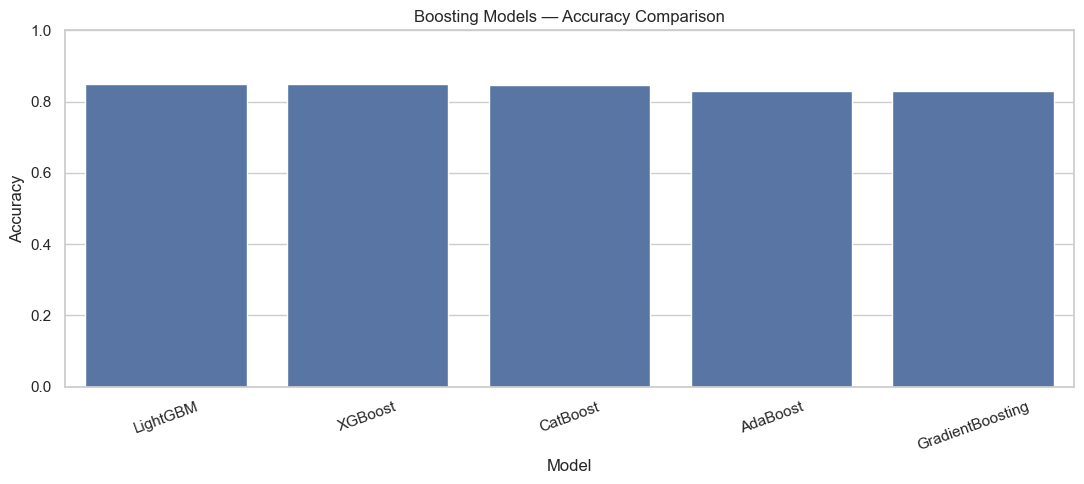

In [10]:
# 11. Accuracy comparison

plt.figure(figsize=(11, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Boosting Models — Accuracy Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


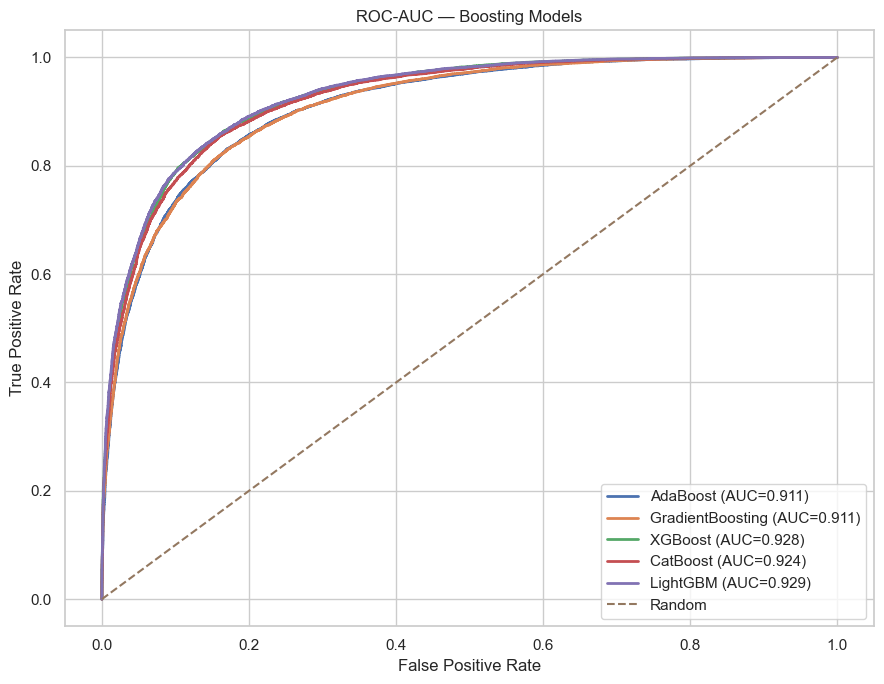

In [11]:
# 12. ROC curves for all boosting models

plt.figure(figsize=(9, 7))

for name, prob in test_probabilities.items():

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC — Boosting Models")
plt.legend()
plt.tight_layout()
plt.show()


# 13. Stacking Ensemble

Base estimators:

- AdaBoost
- GradientBoosting
- XGBoost
- CatBoost
- LightGBM

Meta learner:

- RandomForest

`stack_method="predict_proba"` ব্যবহার করা হয়েছে, অর্থাৎ base models-এর probability outputs meta learner-এর input হবে।


In [14]:
# 13. Create Stacking Classifier

stack_estimators = [
    (
        "ada",
        AdaBoostClassifier(
            n_estimators=150,
            learning_rate=0.5,
            random_state=SEED
        )
    ),

    (
        "gb",
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=SEED
        )
    ),

    (
        "xgb",
        XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1
        )
    ),

    (
        "cat",
        CatBoostClassifier(
            iterations=250,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            verbose=False,
            random_seed=SEED,
            thread_count=-1
        )
    ),

    (
        "lgbm",
        LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )
    )
]

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=RandomForestClassifier(
        n_estimators=250,
        random_state=SEED,
        n_jobs=-1
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print(stack_model)


StackingClassifier(cv=5,
                   estimators=[('ada',
                                AdaBoostClassifier(learning_rate=0.5,
                                                   n_estimators=150,
                                                   random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=150,
                                                           random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early...
  

In [18]:
# 14. Train Stacking Ensemble

print("Training Stacking Ensemble...")

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_prob = stack_model.predict_proba(X_test)[:, 1]

stack_accuracy = accuracy_score(y_test, stack_pred)
stack_precision = precision_score(y_test, stack_pred)
stack_recall = recall_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_prob)

print("\nStacking Ensemble Results")
print("-" * 40)
print(f"Accuracy : {stack_accuracy:.4f}")
print(f"Precision: {stack_precision:.4f}")
print(f"Recall   : {stack_recall:.4f}")
print(f"F1       : {stack_f1:.4f}")
print(f"ROC-AUC  : {stack_auc:.4f}")


Training Stacking Ensemble...

Stacking Ensemble Results
----------------------------------------
Accuracy : 0.8453
Precision: 0.8452
Recall   : 0.8454
F1       : 0.8453
ROC-AUC  : 0.9235


In [19]:
# 15. Add Stacking result

stack_result = pd.DataFrame([{
    "Model": "Stacking Ensemble",
    "Accuracy": stack_accuracy,
    "Precision": stack_precision,
    "Recall": stack_recall,
    "F1": stack_f1,
    "ROC-AUC": stack_auc
}])

final_results = pd.concat(
    [results_df, stack_result],
    ignore_index=True
).sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(final_results)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.84904,0.852994,0.84344,0.848190,0.929321
1,XGBoost,0.84864,0.854482,0.84040,0.847382,0.928032
2,CatBoost,0.84604,0.849648,0.84088,0.845241,0.924212
3,Stacking Ensemble,0.84528,0.845170,0.84544,0.845305,0.923472
4,AdaBoost,0.83000,0.830741,0.82888,0.829809,0.910600
5,GradientBoosting,0.82944,0.836273,0.81928,0.827689,0.911146


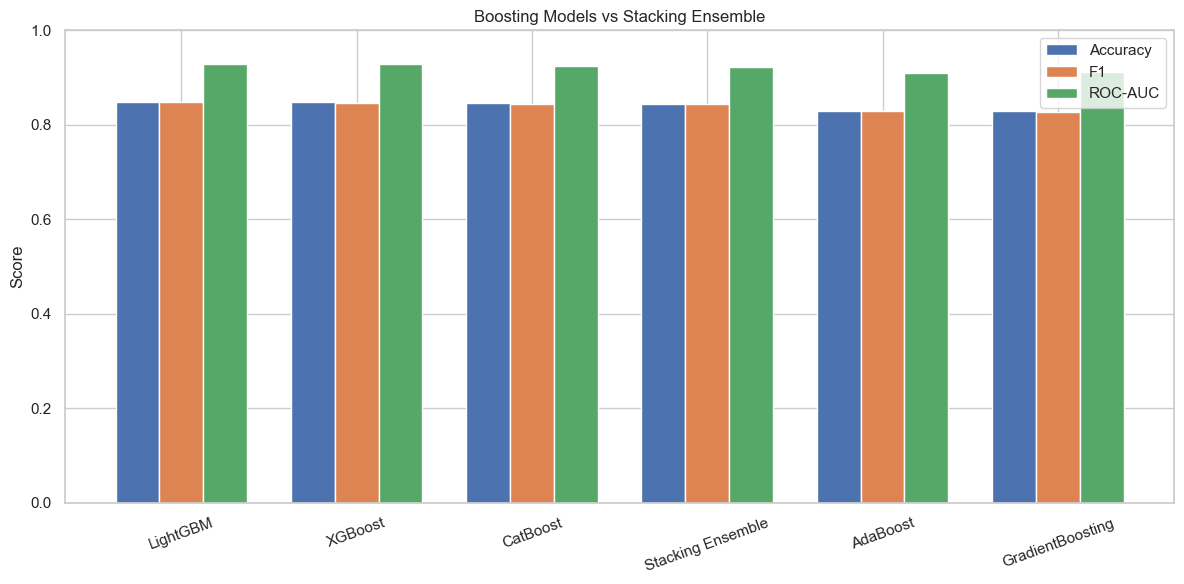

In [20]:
# 16. Final model comparison visualization

plt.figure(figsize=(12, 6))

x = np.arange(len(final_results))
width = 0.25

plt.bar(
    x - width,
    final_results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x,
    final_results["F1"],
    width,
    label="F1"
)

plt.bar(
    x + width,
    final_results["ROC-AUC"],
    width,
    label="ROC-AUC"
)

plt.xticks(
    x,
    final_results["Model"],
    rotation=20
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Boosting Models vs Stacking Ensemble")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
# 17. Classification report — Stacking Ensemble

print(
    classification_report(
        y_test,
        stack_pred,
        target_names=["Negative", "Positive"],
        digits=4
    )
)


              precision    recall  f1-score   support

    Negative     0.8454    0.8451    0.8453     12500
    Positive     0.8452    0.8454    0.8453     12500

    accuracy                         0.8453     25000
   macro avg     0.8453    0.8453    0.8453     25000
weighted avg     0.8453    0.8453    0.8453     25000



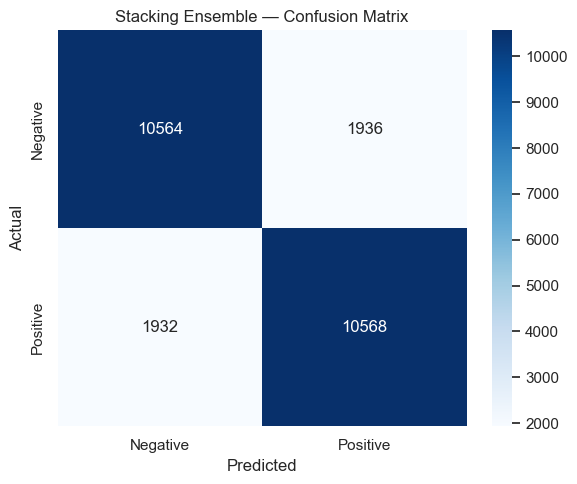

In [23]:
# 18. Confusion Matrix

cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Ensemble — Confusion Matrix")
plt.tight_layout()
plt.show()


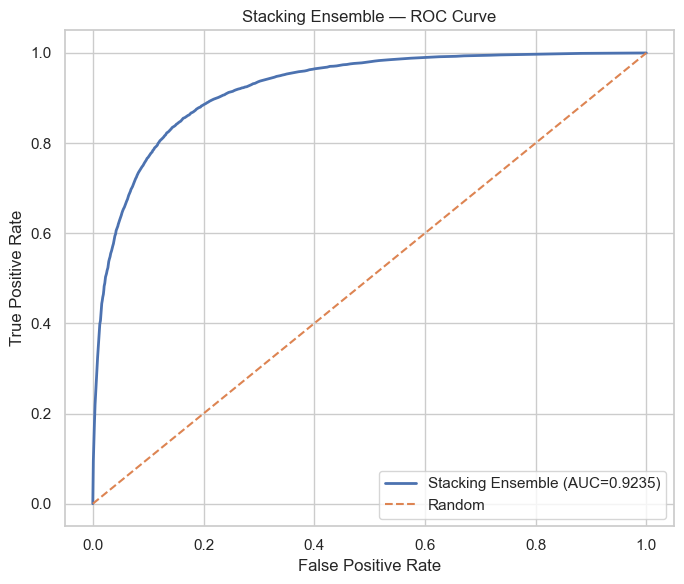

In [24]:
# 19. ROC curve — Stacking Ensemble

fpr, tpr, _ = roc_curve(
    y_test,
    stack_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Stacking Ensemble (AUC={stack_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stacking Ensemble — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# 20. Prediction function for a new IMDB review

def predict_sentiment(review):

    tokens = clean_and_tokenize(review)

    vector = document_vector(
        tokens,
        w2v_model
    ).reshape(1, -1)

    probability_positive = float(
        stack_model.predict_proba(vector)[0, 1]
    )

    sentiment = (
        "Positive"
        if probability_positive >= 0.5
        else "Negative"
    )

    return {
        "sentiment": sentiment,
        "positive_probability": round(
            probability_positive, 4
        ),
        "negative_probability": round(
            1 - probability_positive, 4
        )
    }


example_review = (
    "This movie was fantastic. "
    "The acting was excellent and I really enjoyed it."
)

print(predict_sentiment(example_review))


{'sentiment': 'Positive', 'positive_probability': 0.892, 'negative_probability': 0.108}


In [26]:
# 21. Save complete inference artifacts

os.makedirs("artifacts", exist_ok=True)

w2v_model.save(
    "artifacts/imdb_word2vec.model"
)

joblib.dump(
    stack_model,
    "artifacts/imdb_word2vec_stacking_model.joblib"
)

final_results.to_csv(
    "artifacts/model_comparison.csv",
    index=False
)

print("Saved successfully:")
print("1. artifacts/imdb_word2vec.model")
print("2. artifacts/imdb_word2vec_stacking_model.joblib")
print("3. artifacts/model_comparison.csv")


Saved successfully:
1. artifacts/imdb_word2vec.model
2. artifacts/imdb_word2vec_stacking_model.joblib
3. artifacts/model_comparison.csv


In [27]:
# 22. Save individual boosting models

for name, model in fitted_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + "_word2vec_model.joblib"
    )

    joblib.dump(
        model,
        f"artifacts/{filename}"
    )

print("Individual models saved.")


Individual models saved.


# Final Pipeline

**Hugging Face IMDB → Text Cleaning → Word2Vec → Mean Word Embedding →**

**AdaBoost + GradientBoosting + XGBoost + CatBoost + LightGBM →**

**StackingClassifier → RandomForest Meta Learner →**

**Accuracy + F1 + Confusion Matrix + ROC-AUC**

### Important

এই notebook-এ Word2Vec vocabulary/weights শুধুমাত্র training reviews থেকে শেখানো হয়েছে। Test reviews শুধু `transform`/document-vector তৈরির জন্য ব্যবহার হয়েছে। ফলে test data দিয়ে Word2Vec train করার leakage এড়ানো হয়েছে।

Hugging Face-এর বর্তমান documentation/examples-এ `stanfordnlp/imdb` ব্যবহার করে `load_dataset()` দিয়ে IMDB load করার পদ্ধতি দেখানো হয়েছে।
